In [1]:
# ──Imports + Output Directory ───────────────────────
import os, warnings
warnings.filterwarnings("ignore")

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn           as sns
from scipy               import stats

OUT   = "output/02_eda"
os.makedirs(OUT, exist_ok=True)

EMOTIONS = ["angry", "happy", "neutral", "sad", "surprise"]
COLORS   = {"angry"  : "#e74c3c",
            "happy"  : "#2ecc71",
            "neutral": "#95a5a6",
            "sad"    : "#3498db",
            "surprise":"#f39c12"}

# F41 feature families
FAMILIES = {
    "Pixel"   : ["brightness_mean", "lower_edge_density"],
    "HOG"     : [f"hog_h{i:02d}"  for i in range(16)],
    "LBP"     : [f"lbp_h{i:02d}"  for i in range(6)],
    "Eyes"    : ["ear_L", "ear_R"],
    "Brows"   : ["brow_eye_L", "brow_eye_R", "inter_brow",
                "brow_raise_L", "brow_raise_R"],
    "Mouth"   : ["MAR", "lip_pull", "lip_droop", "mouth_curl",
                "lip_tight", "jaw_open"],
    "Cheeks"  : ["cheek_L", "cheek_R"],
    "Global"  : ["nose_lip", "face_AR"],
}
FAM_COLORS = {"Pixel":"#8e44ad","HOG":"#2980b9","LBP":"#16a085",
            "Eyes":"#27ae60","Brows":"#e67e22",
            "Mouth":"#e74c3c","Cheeks":"#f39c12","Global":"#7f8c8d"}

print(f"Output dir : {OUT}")
print(f"Families   :")
total = 0
for fam, feats in FAMILIES.items():
    print(f"  {fam:<10}: {len(feats):>2} features  {feats[:3]}{'...' if len(feats)>3 else ''}")
    total += len(feats)
print(f"  {'TOTAL':<10}: {total}")

Output dir : output/02_eda
Families   :
  Pixel     :  2 features  ['brightness_mean', 'lower_edge_density']
  HOG       : 16 features  ['hog_h00', 'hog_h01', 'hog_h02']...
  LBP       :  6 features  ['lbp_h00', 'lbp_h01', 'lbp_h02']...
  Eyes      :  2 features  ['ear_L', 'ear_R']
  Brows     :  5 features  ['brow_eye_L', 'brow_eye_R', 'inter_brow']...
  Mouth     :  6 features  ['MAR', 'lip_pull', 'lip_droop']...
  Cheeks    :  2 features  ['cheek_L', 'cheek_R']
  Global    :  2 features  ['nose_lip', 'face_AR']
  TOTAL     : 41


In [2]:
# ── Load CSVs ────────────────────────────────────────
TRAIN_CSV = "csv/features_train_F41.csv"
TEST_CSV  = "csv/features_test_F41.csv"

df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)
df_all   = pd.concat([df_train.assign(split="train"),
                    df_test.assign(split="test")], ignore_index=True)

FEATURE_NAMES = [c for c in df_train.columns if c != "label"]
assert len(FEATURE_NAMES) == 41, f"Expected 41, got {len(FEATURE_NAMES)}"

print(f"Train : {df_train.shape}")
print(f"Test  : {df_test.shape}")
print(f"Total : {df_all.shape}")
print(f"\nClass distribution (train):")
for v, c in zip(*np.unique(df_train['label'], return_counts=True)):
    pct = c / len(df_train) * 100
    bar = '█' * int(pct / 2)
    print(f"  {v:<10}: {c:>5}  ({pct:.1f}%)  {bar}")
print(f"\nClass distribution (test):")
for v, c in zip(*np.unique(df_test['label'], return_counts=True)):
    pct = c / len(df_test) * 100
    print(f"  {v:<10}: {c:>5}  ({pct:.1f}%)")

Train : (24176, 42)
Test  : (6043, 42)
Total : (30219, 43)

Class distribution (train):
  angry     :  3995  (16.5%)  ████████
  happy     :  7215  (29.8%)  ██████████████
  neutral   :  4965  (20.5%)  ██████████
  sad       :  4830  (20.0%)  █████████
  surprise  :  3171  (13.1%)  ██████

Class distribution (test):
  angry     :   958  (15.9%)
  happy     :  1774  (29.4%)
  neutral   :  1233  (20.4%)
  sad       :  1247  (20.6%)
  surprise  :   831  (13.8%)


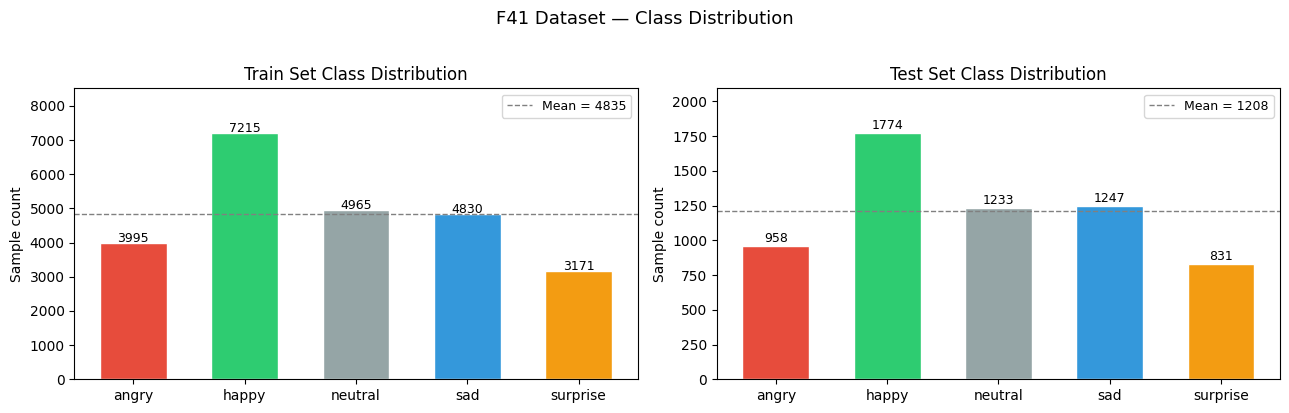

Saved: output/02_eda/01_class_distribution.png


In [3]:
# ── Class Distribution Plot ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (df, title) in zip(axes, [(df_train, "Train"), (df_test, "Test")]):
    counts = df["label"].value_counts().reindex(EMOTIONS)
    bars   = ax.bar(EMOTIONS, counts.values,
                    color=[COLORS[e] for e in EMOTIONS],
                    width=0.6, edgecolor="white")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 30,
                str(v), ha="center", fontsize=9)
    ax.set_title(f"{title} Set Class Distribution", fontsize=12)
    ax.set_ylabel("Sample count")
    ax.set_ylim(0, counts.max() * 1.18)
    ax.axhline(counts.mean(), color="grey", ls="--", lw=1,
            label=f"Mean = {int(counts.mean())}")
    ax.legend(fontsize=9)

plt.suptitle("F41 Dataset — Class Distribution", fontsize=13, y=1.02)
plt.tight_layout()
p = f"{OUT}/01_class_distribution.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

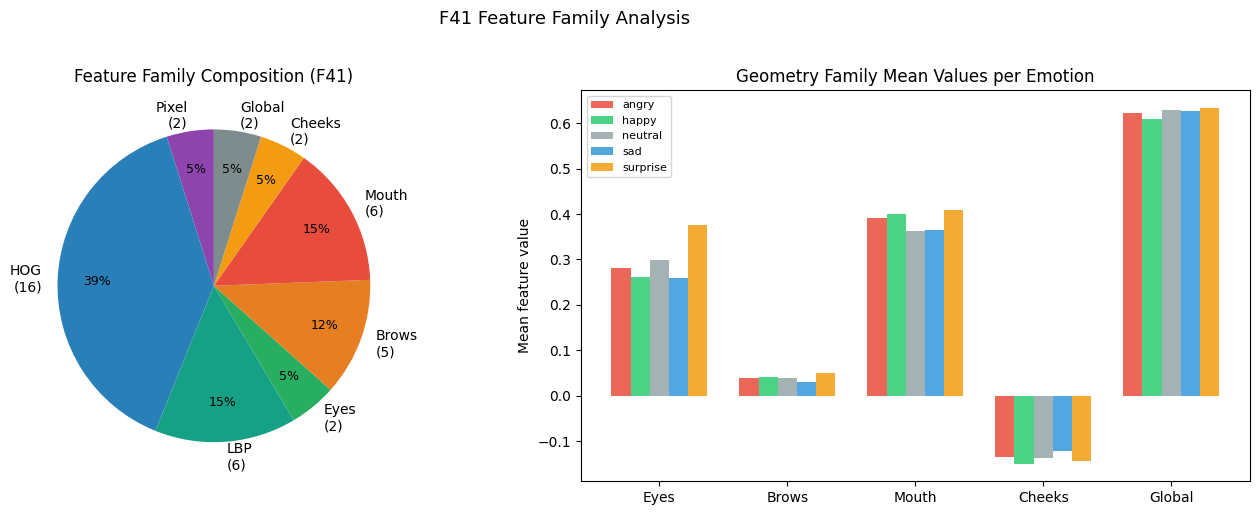

Saved: output/02_eda/02_feature_families.png


In [4]:
# ── Feature Family Overview ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: family sizes pie
fam_sizes  = {f: len(feats) for f, feats in FAMILIES.items()}
pie_colors = [FAM_COLORS[f] for f in fam_sizes]
wedges, texts, autotexts = axes[0].pie(
    fam_sizes.values(),
    labels     = [f"{f}\n({n})" for f, n in fam_sizes.items()],
    colors     = pie_colors,
    autopct    = "%1.0f%%",
    startangle = 90,
    pctdistance= 0.75,
)
for t in autotexts:
    t.set_fontsize(9)
axes[0].set_title("Feature Family Composition (F41)", fontsize=12)

# Right: per-family mean absolute value per emotion (geometry only)
geo_families = {k: v for k, v in FAMILIES.items()
                if k not in ("HOG", "LBP", "Pixel")}
n_fam  = len(geo_families)
x      = np.arange(n_fam)
width  = 0.15
fam_names = list(geo_families.keys())

for i, emo in enumerate(EMOTIONS):
    vals = []
    for fam, feats in geo_families.items():
        vals.append(df_train.loc[df_train["label"]==emo, feats].mean().mean())
    offset = (i - len(EMOTIONS)/2 + 0.5) * width
    axes[1].bar(x + offset, vals, width, label=emo,
                color=COLORS[emo], alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(fam_names, fontsize=10)
axes[1].set_ylabel("Mean feature value")
axes[1].set_title("Geometry Family Mean Values per Emotion", fontsize=12)
axes[1].legend(fontsize=8)

plt.suptitle("F41 Feature Family Analysis", fontsize=13, y=1.02)
plt.tight_layout()
p = f"{OUT}/02_feature_families.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

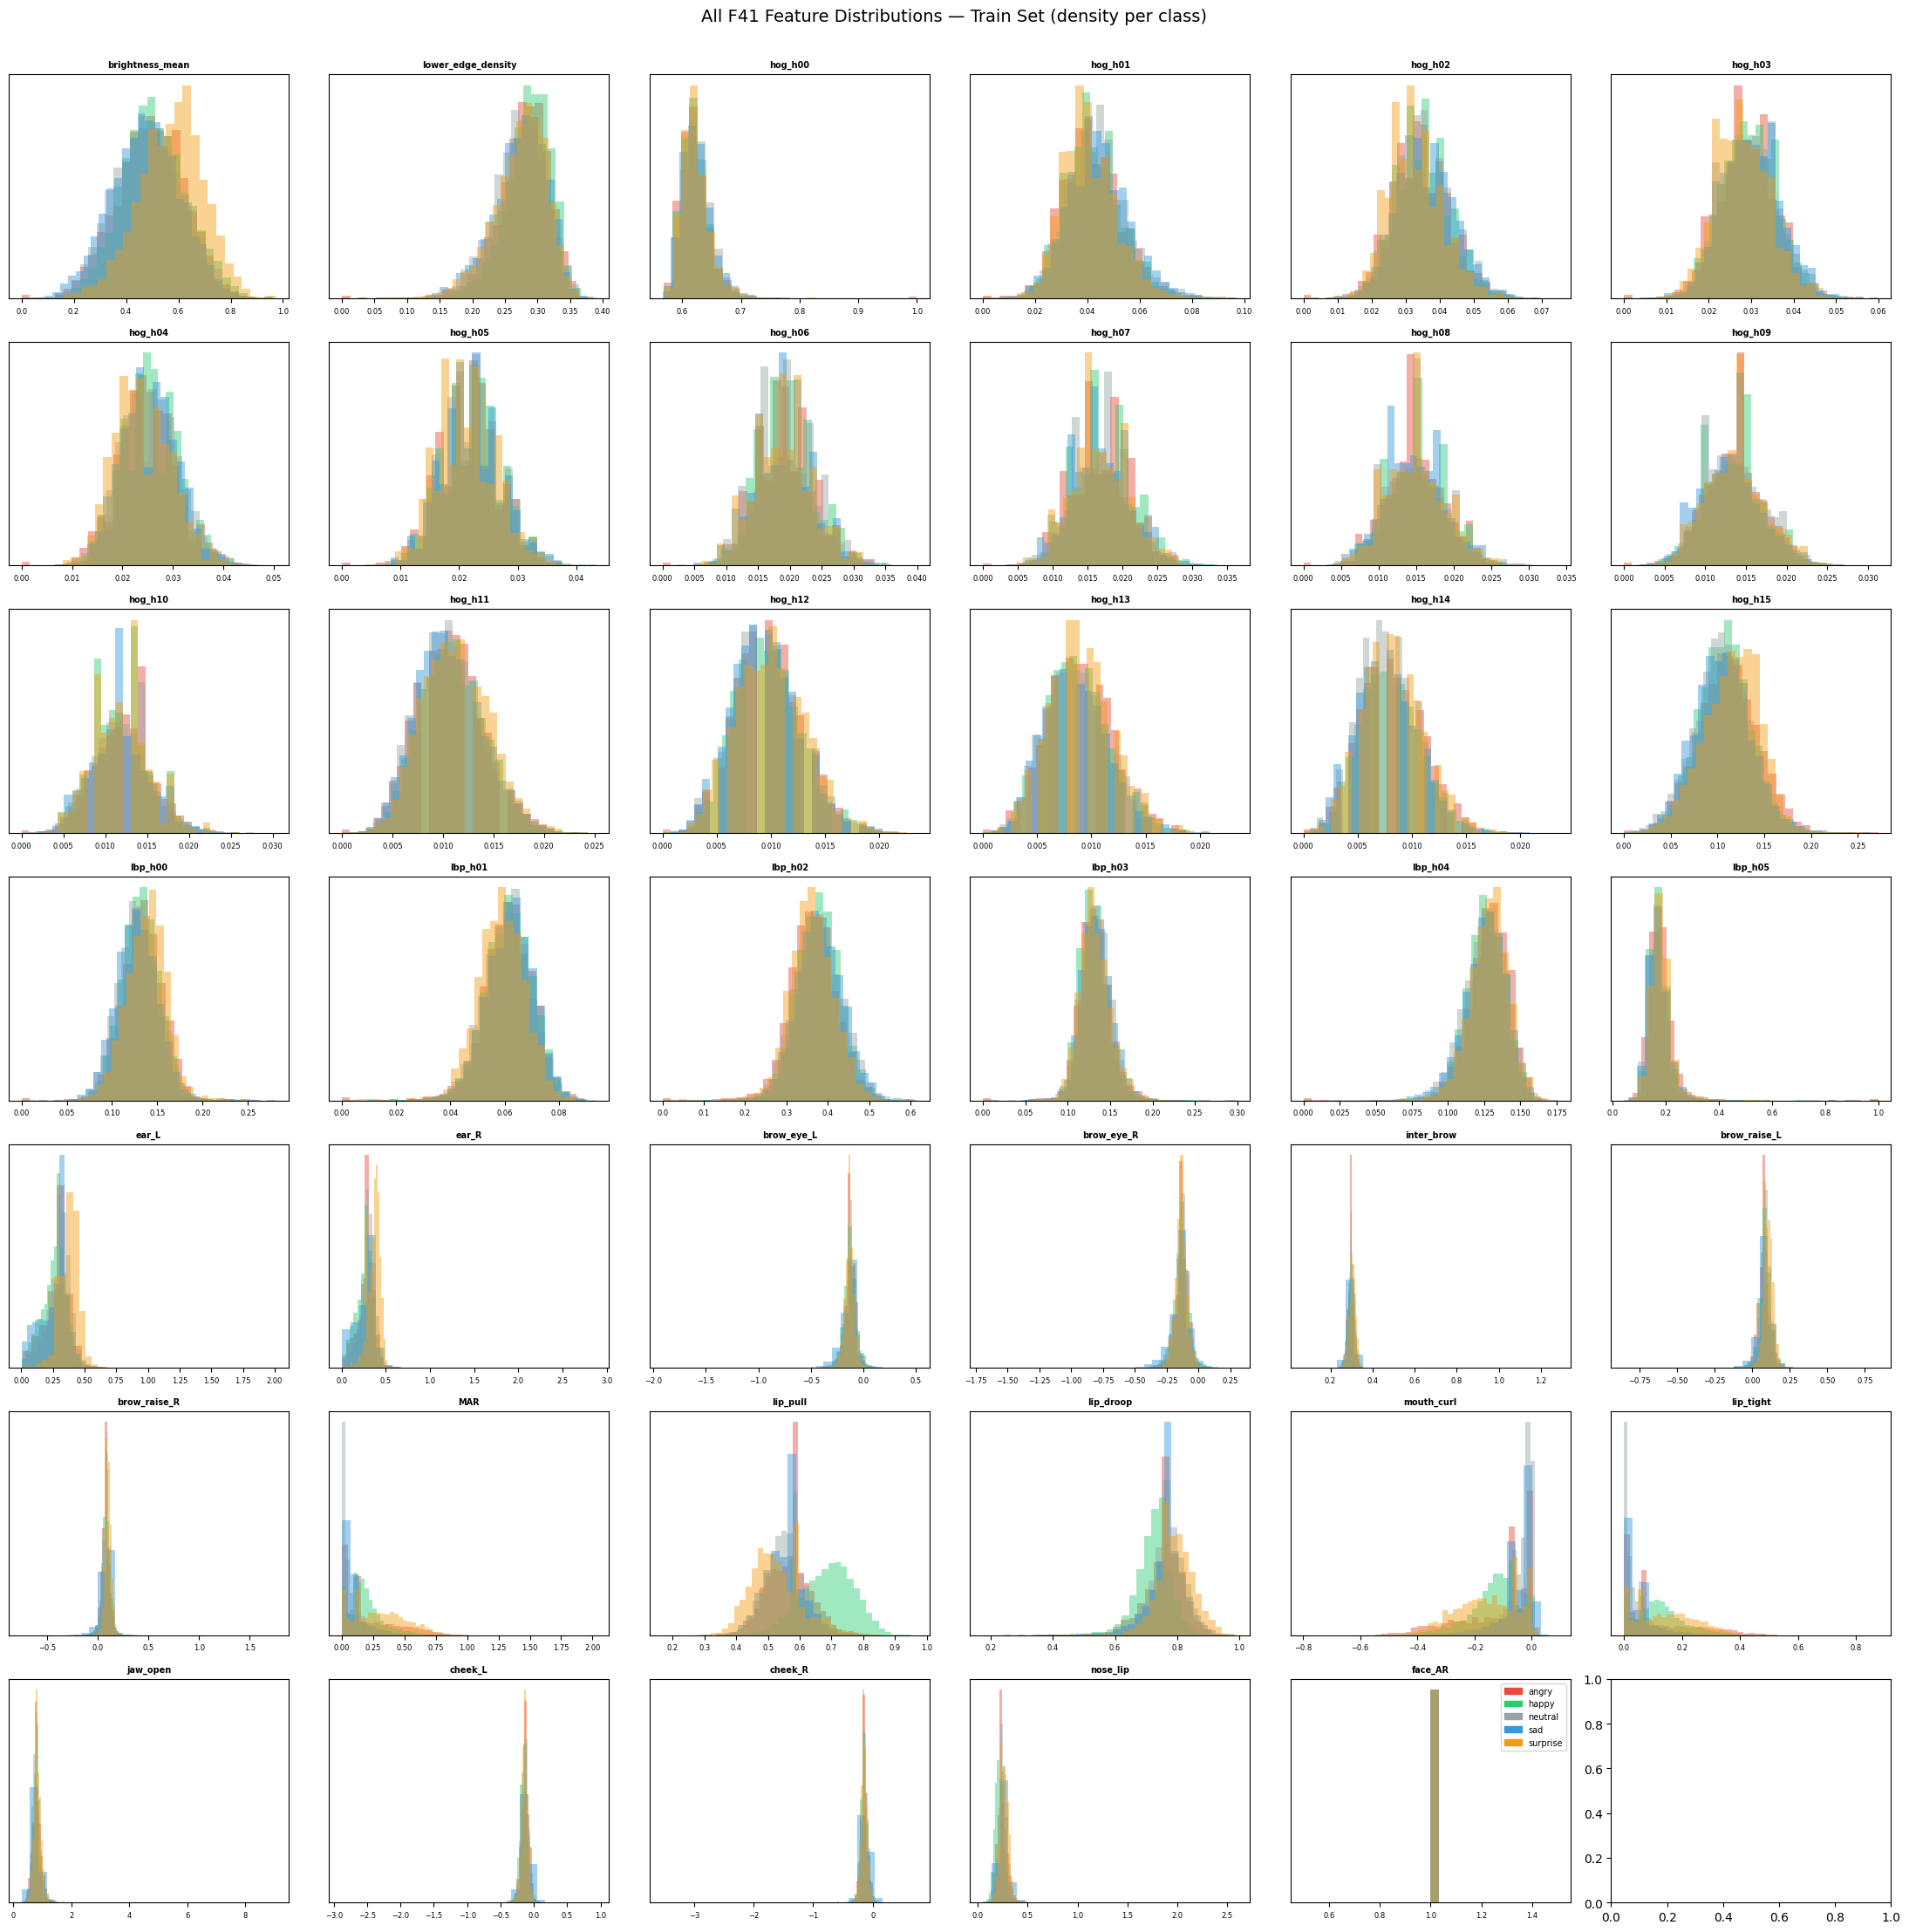

Saved: output/02_eda/03_all_feature_distributions.png


In [5]:
# ── All 41 Feature Distributions (per class) ─────────
# 7 rows × 6 cols = 42 panels (last panel = empty)
ncols = 6
nrows = 7
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 22))
axes_flat = axes.flat

for ax, feat in zip(axes_flat, FEATURE_NAMES):
    for emo in EMOTIONS:
        vals = df_train.loc[df_train["label"] == emo, feat].dropna()
        ax.hist(vals, bins=30, alpha=0.45,
                color=COLORS[emo], label=emo, density=True)
    ax.set_title(feat, fontsize=7, fontweight="bold")
    ax.tick_params(labelsize=6)
    ax.set_yticks([])

# Hide unused panel
for ax in list(axes_flat)[len(FEATURE_NAMES):]:
    ax.axis("off")

# Legend on last used panel
handles = [plt.Rectangle((0,0),1,1, color=COLORS[e]) for e in EMOTIONS]
axes_flat[len(FEATURE_NAMES)-1].legend(handles, EMOTIONS,
                                        fontsize=7, loc="upper right")

plt.suptitle("All F41 Feature Distributions — Train Set (density per class)",
            fontsize=14, y=1.005)
plt.tight_layout()
p = f"{OUT}/03_all_feature_distributions.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

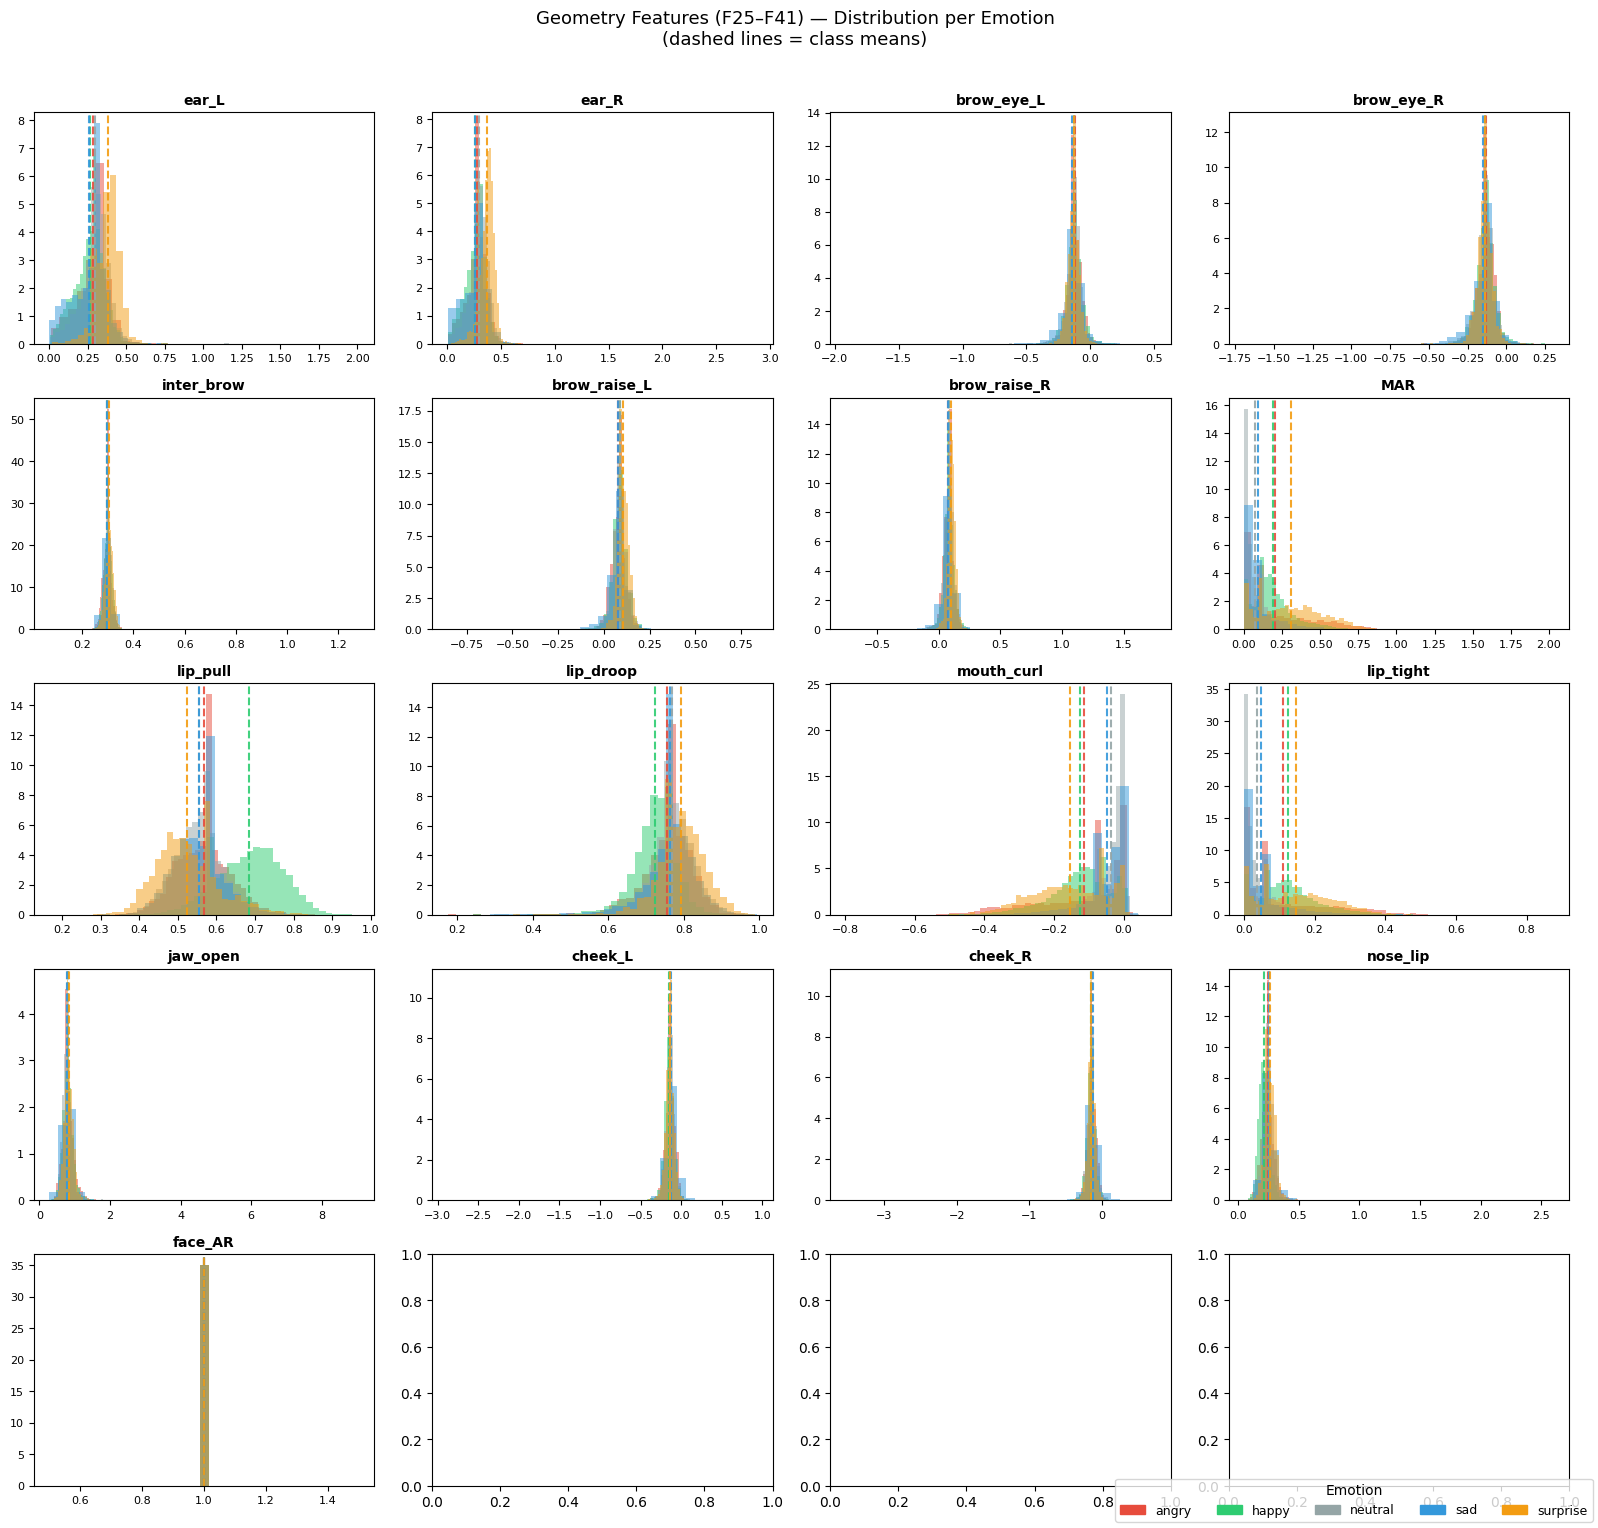

Saved: output/02_eda/04_geometry_distributions.png


In [6]:
# ── Geometry Feature Distributions (detailed) ────────
geo_feats = (FAMILIES["Eyes"] + FAMILIES["Brows"] +
            FAMILIES["Mouth"] + FAMILIES["Cheeks"] + FAMILIES["Global"])

ncols = 4
nrows = (len(geo_feats) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes_flat = axes.flat

for ax, feat in zip(axes_flat, geo_feats):
    for emo in EMOTIONS:
        vals = df_train.loc[df_train["label"] == emo, feat].dropna()
        ax.hist(vals, bins=35, alpha=0.5,
                color=COLORS[emo], label=emo, density=True)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)

    # Add class means as vertical lines
    for emo in EMOTIONS:
        mu = df_train.loc[df_train["label"] == emo, feat].mean()
        ax.axvline(mu, color=COLORS[emo], lw=1.5, ls="--", alpha=0.9)

for ax in list(axes_flat)[len(geo_feats):]:
    ax.axis("off")

handles = [plt.Rectangle((0,0),1,1, color=COLORS[e]) for e in EMOTIONS]
fig.legend(handles, EMOTIONS, loc="lower right",
        fontsize=9, title="Emotion", ncol=5)

plt.suptitle("Geometry Features (F25–F41) — Distribution per Emotion\n"
            "(dashed lines = class means)", fontsize=13, y=1.01)
plt.tight_layout()
p = f"{OUT}/04_geometry_distributions.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

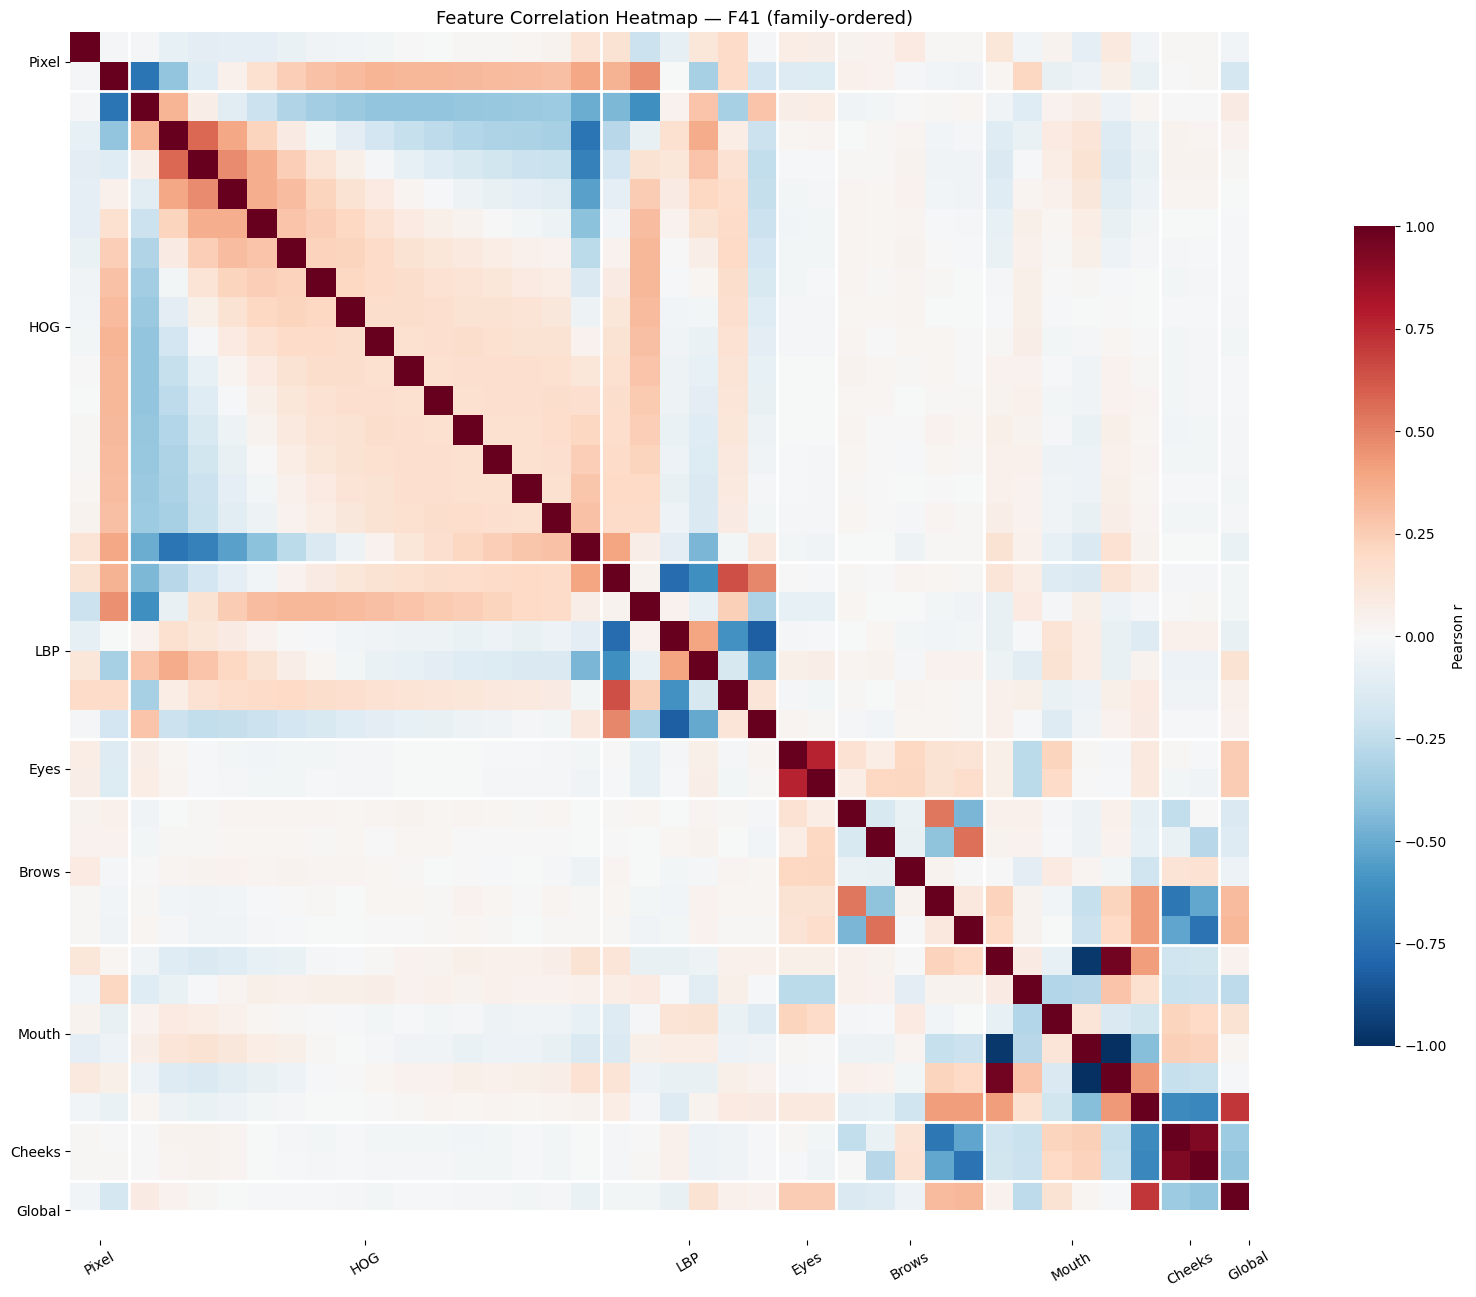

Saved: output/02_eda/05_correlation_heatmap.png

Top correlated pairs (|r| > 0.70):
                f1         f2         r
               MAR  lip_tight  0.966018
           cheek_L    cheek_R  0.933609
             ear_L      ear_R  0.769671
          jaw_open   nose_lip  0.716368
      brow_raise_L    cheek_L -0.723119
lower_edge_density    hog_h00 -0.727385
           hog_h01    hog_h15 -0.728154
      brow_raise_R    cheek_R -0.739090
           lbp_h00    lbp_h02 -0.770815
           lbp_h02    lbp_h05 -0.824404
               MAR mouth_curl -0.964837
        mouth_curl  lip_tight -0.995848


In [7]:
# ── Feature Correlation Heatmap ─────────────────────
corr = df_train[FEATURE_NAMES].corr()

# Build family-ordered feature list
feat_order = []
for feats in FAMILIES.values():
    feat_order.extend(feats)
corr_ordered = corr.loc[feat_order, feat_order]

# Family boundary ticks
boundaries = []
tick_pos   = []
tick_labels= []
pos = 0
for fam, feats in FAMILIES.items():
    tick_pos.append(pos + len(feats) / 2)
    tick_labels.append(fam)
    pos += len(feats)
    boundaries.append(pos)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_ordered, ax=ax, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True,
            xticklabels=False, yticklabels=False,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"})

# Family dividers
for b in boundaries[:-1]:
    ax.axhline(b, color="white", lw=2)
    ax.axvline(b, color="white", lw=2)

ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=10, rotation=30)
ax.set_yticks(tick_pos)
ax.set_yticklabels(tick_labels, fontsize=10, rotation=0)
ax.set_title("Feature Correlation Heatmap — F41 (family-ordered)", fontsize=13)
plt.tight_layout()
p = f"{OUT}/05_correlation_heatmap.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

# Print top 10 highly correlated pairs (|r| > 0.7, exclude self)
print("\nTop correlated pairs (|r| > 0.70):")
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index())
pairs.columns = ["f1","f2","r"]
pairs = pairs[pairs["r"].abs() > 0.70].sort_values("r", ascending=False)
print(pairs.head(15).to_string(index=False))

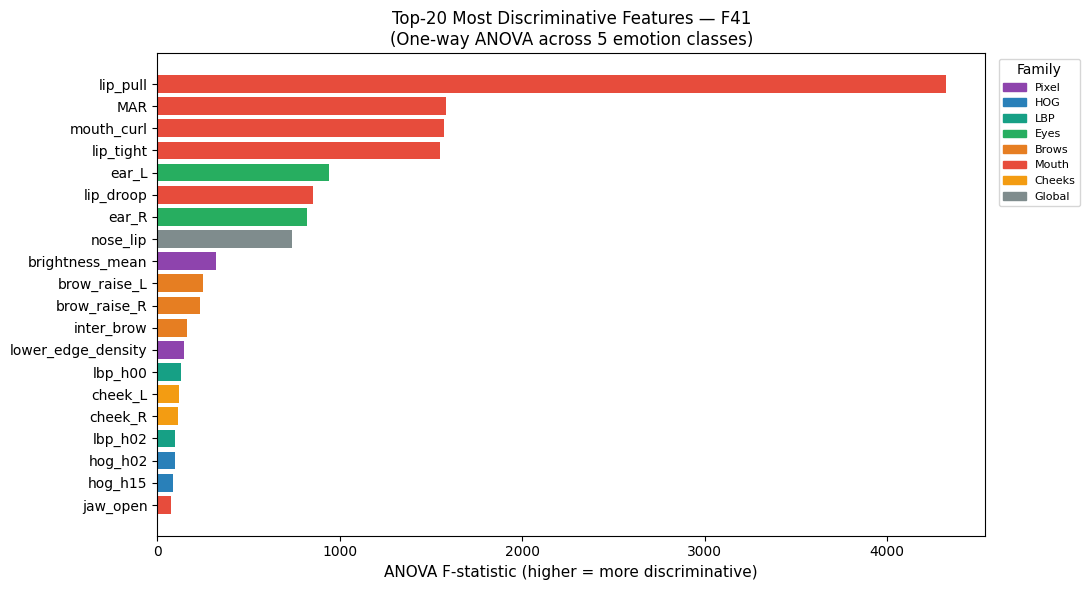

Saved: output/02_eda/06_anova_separability.png
Saved: output/02_eda/06_anova_separability.csv

Top-10 most discriminative features:
        feature      f_stat       p_value
       lip_pull 4320.296755  0.000000e+00
            MAR 1581.311081  0.000000e+00
     mouth_curl 1571.639290  0.000000e+00
      lip_tight 1549.992150  0.000000e+00
          ear_L  942.330943  0.000000e+00
      lip_droop  853.966730  0.000000e+00
          ear_R  818.812584  0.000000e+00
       nose_lip  735.864941  0.000000e+00
brightness_mean  323.134624 2.314725e-271
   brow_raise_L  251.329848 6.307766e-212


In [8]:
# ── Class Separability (ANOVA F-statistic) ───────────
# High F-stat = feature varies a lot between classes → discriminative
f_stats = {}
for feat in FEATURE_NAMES:
    groups = [df_train.loc[df_train["label"]==e, feat].dropna().values
            for e in EMOTIONS]
    f_val, p_val = stats.f_oneway(*groups)
    f_stats[feat] = {"f_stat": f_val, "p_value": p_val}

f_df = (pd.DataFrame(f_stats).T
        .reset_index()
        .rename(columns={"index":"feature"})
        .sort_values("f_stat", ascending=False)
        .reset_index(drop=True))
f_df["significant"] = f_df["p_value"] < 0.05
f_df.to_csv(f"{OUT}/06_anova_separability.csv", index=False)

# Plot top 20
top20 = f_df.head(20)
fam_map = {feat: fam for fam, feats in FAMILIES.items() for feat in feats}
bar_colors = [FAM_COLORS.get(fam_map.get(f, ""), "#999") for f in top20["feature"]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20["feature"][::-1], top20["f_stat"][::-1], color=bar_colors[::-1])
ax.set_xlabel("ANOVA F-statistic (higher = more discriminative)", fontsize=11)
ax.set_title("Top-20 Most Discriminative Features — F41\n"
            "(One-way ANOVA across 5 emotion classes)", fontsize=12)
handles = [plt.Rectangle((0,0),1,1, color=FAM_COLORS[f], label=f)
        for f in FAM_COLORS]
ax.legend(handles=handles, fontsize=8, title="Family",
        bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
p = f"{OUT}/06_anova_separability.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")
print(f"Saved: {OUT}/06_anova_separability.csv")
print(f"\nTop-10 most discriminative features:")
print(f_df.head(10)[["feature","f_stat","p_value"]].to_string(index=False))

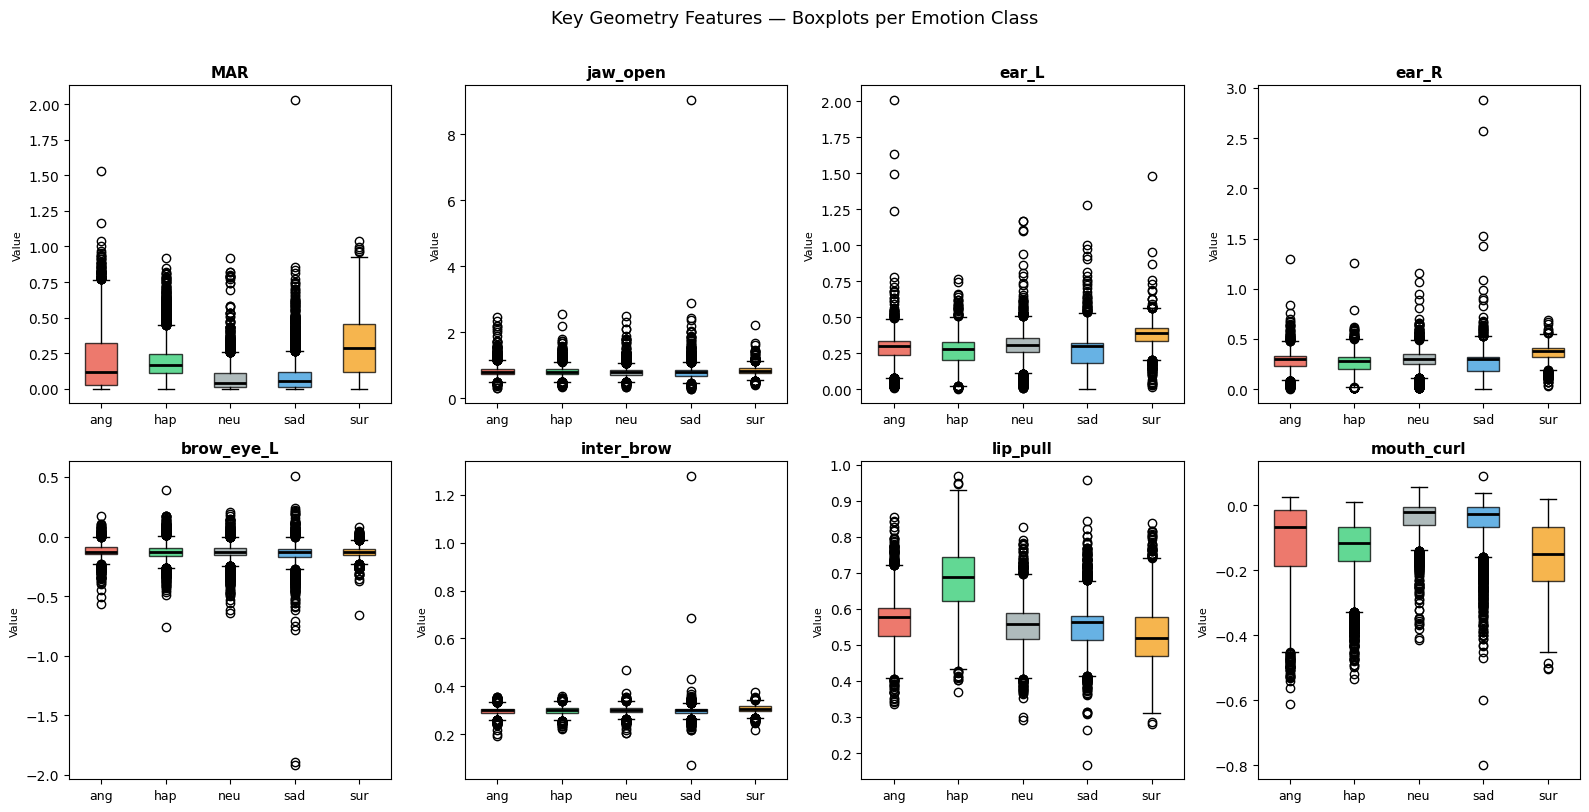

Saved: output/02_eda/07_geometry_boxplots.png


In [9]:
# ── Key Geometry Feature Boxplots ────────────────────
key_feats = ["MAR", "jaw_open", "ear_L", "ear_R",
            "brow_eye_L", "inter_brow", "lip_pull", "mouth_curl"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, feat in zip(axes.flat, key_feats):
    data   = [df_train.loc[df_train["label"]==e, feat].dropna().values
            for e in EMOTIONS]
    bp     = ax.boxplot(data, patch_artist=True, notch=False,
                        medianprops={"color":"black","lw":2})
    for patch, emo in zip(bp["boxes"], EMOTIONS):
        patch.set_facecolor(COLORS[emo])
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels([e[:3] for e in EMOTIONS], fontsize=9)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_ylabel("Value", fontsize=8)

plt.suptitle("Key Geometry Features — Boxplots per Emotion Class",
            fontsize=13, y=1.01)
plt.tight_layout()
p = f"{OUT}/07_geometry_boxplots.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

In [10]:
# ── Statistical Summary Report ──────────────────────
# Per-class mean ± std for all geometry features
geo_feats = (FAMILIES["Eyes"] + FAMILIES["Brows"] +
            FAMILIES["Mouth"] + FAMILIES["Cheeks"] + FAMILIES["Global"])

rows = []
for feat in geo_feats:
    row = {"feature": feat}
    for emo in EMOTIONS:
        vals = df_train.loc[df_train["label"]==emo, feat].dropna()
        row[f"{emo}_mean"] = round(vals.mean(), 4)
        row[f"{emo}_std"]  = round(vals.std(),  4)
    # signal ratio: max class mean / min class mean
    means = [row[f"{e}_mean"] for e in EMOTIONS]
    row["signal_ratio"] = round(max(means) / (min(means) + 1e-6), 3)
    rows.append(row)

summary_df = pd.DataFrame(rows).sort_values("signal_ratio", ascending=False)
summary_df.to_csv(f"{OUT}/08_geometry_stats.csv", index=False)

print("Geometry Feature Stats (sorted by signal ratio):")
print(summary_df[["feature","signal_ratio"] +
                [f"{e}_mean" for e in EMOTIONS]].to_string(index=False))
print(f"\nSaved: {OUT}/08_geometry_stats.csv")

# Missing value check
nan_counts = df_train[FEATURE_NAMES].isna().sum()
nan_feats  = nan_counts[nan_counts > 0]
print(f"\nNaN counts in train: {len(nan_feats)} features with NaNs")
if len(nan_feats):
    print(nan_feats.to_string())
else:
    print("No missing values")

Geometry Feature Stats (sorted by signal ratio):
     feature  signal_ratio  angry_mean  happy_mean  neutral_mean  sad_mean  surprise_mean
         MAR         4.349      0.2024      0.1885        0.0702    0.0909         0.3053
   lip_tight         4.091      0.1118      0.1250        0.0363    0.0495         0.1485
       ear_L         1.464      0.2826      0.2626        0.3011    0.2604         0.3811
       ear_R         1.431      0.2778      0.2601        0.2973    0.2578         0.3688
brow_raise_R         1.393      0.0754      0.0827        0.0823    0.0741         0.1032
brow_raise_L         1.366      0.0792      0.0867        0.0864    0.0781         0.1067
    lip_pull         1.302      0.5681      0.6833        0.5537    0.5544         0.5250
    nose_lip         1.226      0.2444      0.2172        0.2558    0.2549         0.2662
   lip_droop         1.096      0.7561      0.7237        0.7683    0.7628         0.7929
    jaw_open         1.063      0.8211      0.8088 

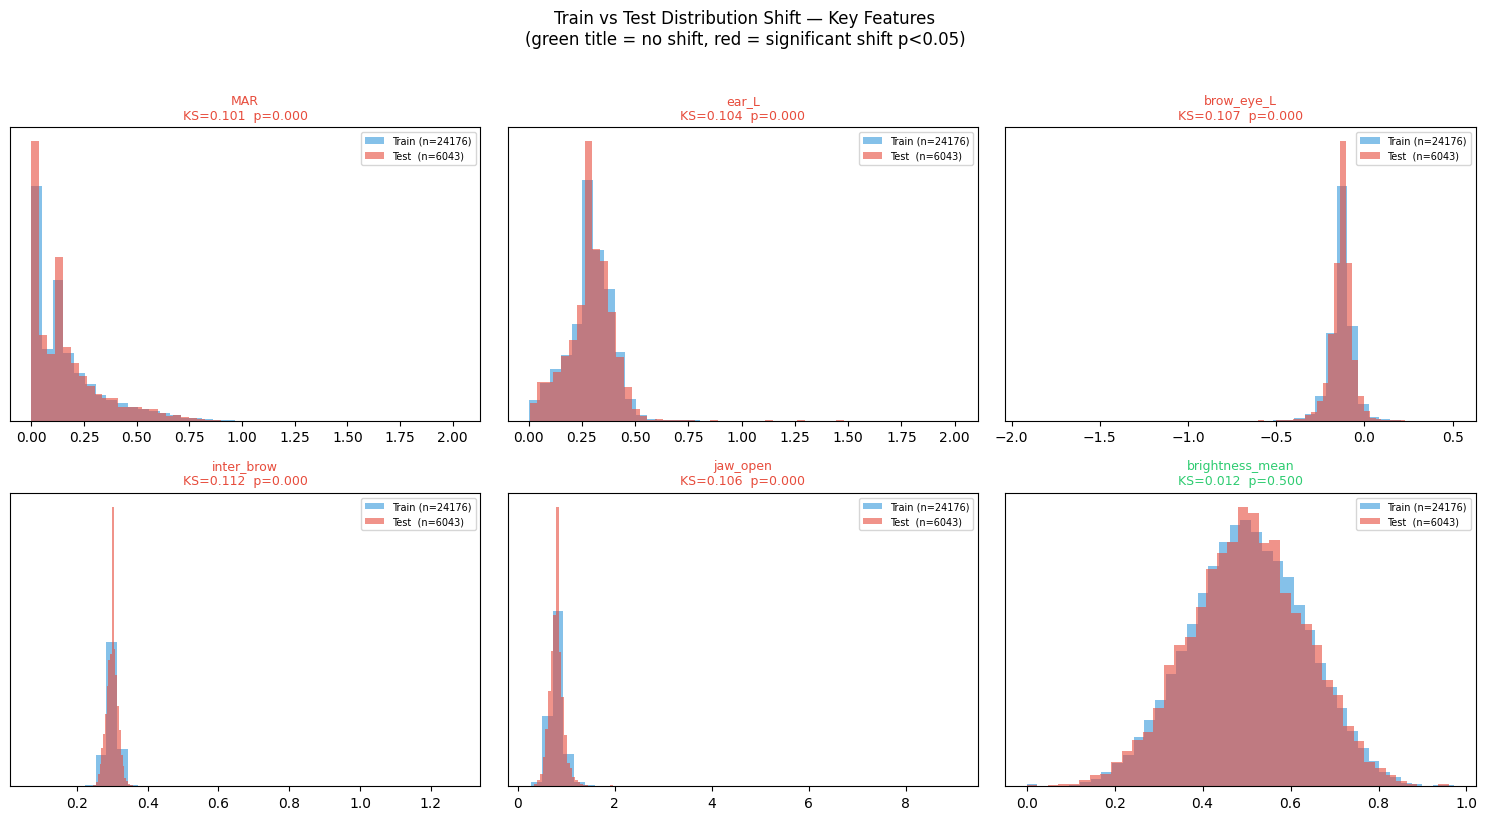

Saved: output/02_eda/09_train_test_shift.png

Kolmogorov-Smirnov test (train vs test):
  MAR                 : KS=0.1014  p=0.0000  ⚠ shift
  ear_L               : KS=0.1044  p=0.0000  ⚠ shift
  brow_eye_L          : KS=0.1065  p=0.0000  ⚠ shift
  inter_brow          : KS=0.1115  p=0.0000  ⚠ shift
  jaw_open            : KS=0.1062  p=0.0000  ⚠ shift
  brightness_mean     : KS=0.0119  p=0.4999  ✅ ok


In [11]:
# ── Train vs Test Distribution Shift ────────────────
# Check if train/test distributions match for key features
key_feats = ["MAR", "ear_L", "brow_eye_L", "inter_brow",
        "jaw_open", "brightness_mean"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
ks_results = []

for ax, feat in zip(axes.flat, key_feats):
        tr_vals = df_train[feat].dropna()
        te_vals = df_test[feat].dropna()

        ax.hist(tr_vals, bins=40, alpha=0.6, color="#3498db",
                density=True, label=f"Train (n={len(tr_vals)})")
        ax.hist(te_vals, bins=40, alpha=0.6, color="#e74c3c",
                density=True, label=f"Test  (n={len(te_vals)})")

        ks_stat, ks_p = stats.ks_2samp(tr_vals, te_vals)
        ks_results.append({"feature": feat, "ks_stat": round(ks_stat,4),
                "p_value": round(ks_p, 4)})
        color  = "#e74c3c" if ks_p < 0.05 else "#2ecc71"
        ax.set_title(f"{feat}\nKS={ks_stat:.3f}  p={ks_p:.3f}",
                fontsize=9, color=color)
        ax.legend(fontsize=7)
        ax.set_yticks([])

plt.suptitle("Train vs Test Distribution Shift — Key Features\n"
        "(green title = no shift, red = significant shift p<0.05)",
        fontsize=12, y=1.02)
plt.tight_layout()
p = f"{OUT}/09_train_test_shift.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")
print("\nKolmogorov-Smirnov test (train vs test):")
for r in ks_results:
        flag = "⚠ shift" if r["p_value"] < 0.05 else "✅ ok"
        print(f"  {r['feature']:<20}: KS={r['ks_stat']:.4f}  p={r['p_value']:.4f}  {flag}")

In [12]:
# ── EDA Summary ─────────────────────────────────────
all_outputs = sorted(os.listdir(OUT))
print(f"{'═'*55}")
print(" Phase 2 EDA — output/02_eda/ Summary")
print(f"{'═'*55}")
print(f" Train samples : {len(df_train)}")
print(f" Test  samples : {len(df_test)}")
print(f" Features      : {len(FEATURE_NAMES)}")
print(f" Classes       : {EMOTIONS}")
print(f"{'─'*55}")
print(f" Files saved to {OUT}/:")
for f in all_outputs:
    kb = os.path.getsize(f"{OUT}/{f}") / 1024
    print(f"   {f:<45} {kb:>7.1f} KB")
print(f"{'═'*55}")


═══════════════════════════════════════════════════════
 Phase 2 EDA — output/02_eda/ Summary
═══════════════════════════════════════════════════════
 Train samples : 24176
 Test  samples : 6043
 Features      : 41
 Classes       : ['angry', 'happy', 'neutral', 'sad', 'surprise']
───────────────────────────────────────────────────────
 Files saved to output/02_eda/:
   01_class_distribution.png                        62.2 KB
   02_feature_families.png                          93.6 KB
   03_all_feature_distributions.png                183.8 KB
   04_geometry_distributions.png                   212.8 KB
   05_correlation_heatmap.png                       80.5 KB
   06_anova_separability.csv                         2.1 KB
   06_anova_separability.png                        76.9 KB
   07_geometry_boxplots.png                        166.3 KB
   08_geometry_stats.csv                             1.5 KB
   09_train_test_shift.png                          74.3 KB
═══════════════════════════════